<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad%203/An%C3%A1lisis_de_Modelos_de_Clasificaci%C3%B3n_en_el_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

In [155]:
train_df = pd.read_csv('Tinanitc-data-train.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#**Parte 1. Preparación del entorno y los datos**

##Análisis exploratorio (EDA)

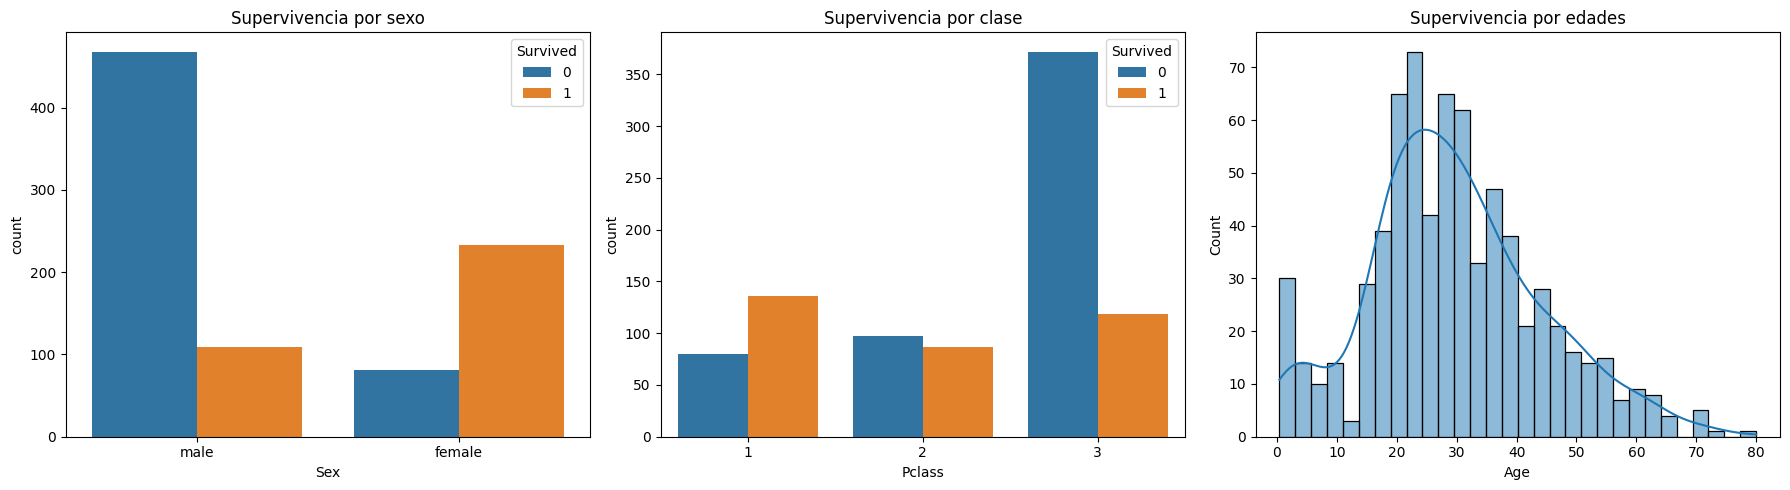

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
# Supervivencia por sexo
sns.countplot(
    x='Sex',
    hue='Survived',
    data=train_df,
    ax=axes[0]
)
axes[0].set_title("Supervivencia por sexo")
# Supervivencia por clase
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=train_df,
    ax=axes[1]
)
axes[1].set_title("Supervivencia por clase")

# Supervivencia por edad
sns.histplot(
    train_df['Age'],
    bins=30,
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Supervivencia por edades")
plt.tight_layout()
plt.show()

##Limpieza de valores nulos

In [157]:
print(train_df.isnull().sum())
train_df['Age'] = train_df['Age'].fillna(
    train_df['Age'].median()
)
train_df['Embarked'] = train_df['Embarked'].fillna(
    train_df['Embarked'].mode()[0]
)
train_df.drop(
    'Cabin',
    axis=1,
    inplace=True
)
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


##Selección de variables significativas
Se seleccionaron las variables más relevantes relacionadas con la supervivencia de los pasajeros del Titanic.
Las variables seleccionadas fueron:


*   Pclass (Clase del pasajero)
*   Sex (Sexo)

*   Age (Edad)
*   SibSp (Familiares a bordo)


*   Parch (Padres/hijos a bordo)
*   Fare (Tarifa pagada)


*   Embarked (puerto de embarque)

Estas variables fueron elegidas porque contienen información importante sobre las condiciones sociales, económicas y familiares de los pasajeros, factores que influyeron directamente en la probabilidad de supervivencia.










##Codificación de variables categóricas

In [158]:
train_df['Sex'] = train_df['Sex'].map({
    'male': 0,
    'female': 1
})
le = LabelEncoder ()
train_df['Embarked'] = le.fit_transform(
    train_df['Embarked']
)

In [159]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
X = train_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = train_df['Survived']

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)


###¿Por qué escalar en KNN y SVM?
Necesitan escalamiento porque utilizan distancias matemáticas para clasificar los datos. Si una variable tiene valores más grandes que otras, tendrá mayor influencia en el modelo y puede afectar negativamente el resultado.
###¿Por qué no es necesario en árboles?
No es necesario escalar porque estos modelos funcionan mediante reglas y divisiones de datos, no mediante cálculos de distancia.

#**Parte 2 y 3. Entrenamiento de modelos y Interpretación**



##Modelo KNN (K-Nearest Neighbors)

In [166]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print("Precisión del modelo:", knn_model.score(X_test_scaled, y_test))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))

Precisión del modelo: 0.7873134328358209

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       165
           1       0.74      0.68      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268


Matriz de confusión:
[[141  24]
 [ 33  70]]


##¿Cómo funciona el algoritmo?
KNN clasifica un pasajero según los k vecinos más cercanos usando distancia entre variables como edad, tarifa, sexo y clase.
Por ejemplo, si la mayoría de sus vecinos sobrevivieron, el modelo predice que también sobrevivió.
##Ventajas


*   Fácil de entender
*   Bueno para relaciones no lineales


*   No requiere entrenamiento complejo
##Limitaciones


*   Sensible al escalado
*   Puede ser lento con muchos datos


*   Sensible a ruido
##Interpretación de resultados
Detecta bien a los no sobrevivientes si el recall de la clase 0 es alto

Detecta a los sobrevivientes de forma aceptable si el recall de la clase 1 es razonable
##Posibles causas del rendimiento


*   Número de vecinos no óptimo


*   Variables con escalas diferentes
*   Datos desbalanceados
##Recomendaciones de mejora


*   Ajustar n_neighbors
*   Probar otras métricas de distancia


*   Crear variables nuevas como familia total


















##Regresión Logística

In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_lr))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       165
           1       0.74      0.71      0.73       103

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268


Matriz de confusión:
[[140  25]
 [ 30  73]]


##¿Cómo funciona?

La Regresión Logística calcula la probabilidad de que un pasajero sobreviva utilizando una función logística.
Si la probabilidad es alta, el modelo clasifica al pasajero como sobreviviente; si es baja, como no sobreviviente.
##Ventajas


*   Fácil interpretación
*   Rápido
*   Bueno como modelo base
##Limitaciones


*   Supone relación lineal
*   Puede fallar con patrones complejos
##Interpretación


*   Suele detectar bien ambas clases
*   Muy útil para comparar con otros modelos
##Posibles causas


*   Relación lineal entre variables y clase
*   Buen escalado de datos
##Mejoras


*   Selección de variables
*   Regularización


*   Interacciones entre variables














##Árbol de Decisión

In [168]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_tree))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       165
           1       0.72      0.65      0.68       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.77      0.77      0.77       268


Matriz de confusión:
[[139  26]
 [ 36  67]]


## ¿Cómo funciona el algoritmo?
El Árbol de Decisión funciona creando reglas lógicas para dividir los datos.  
Realiza preguntas como:

- ¿El pasajero es mujer?
- ¿La clase es primera clase?

Dependiendo de las respuestas, el modelo llega a una clasificación final.


##Ventajas
- Fácil de interpretar
- No requiere escalado

##Limitaciones
- Puede sobreajustarse
- Sensible a ruido

##Interpretación de resultados
- Detecta bien ambas clases si el árbol está bien ajustado

## Posibles causas del rendimiento
- Profundidad excesiva
- Datos limitados

## Recomendaciones de mejora
- Ajustar max_depth
- Poda del árbol
- Selección de variables

##Random Forest

In [169]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       165
           1       0.76      0.66      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268


Matriz de confusión:
[[144  21]
 [ 35  68]]


## ¿Cómo funciona el algoritmo?
Random Forest combina múltiples árboles de decisión.  
Cada árbol realiza una predicción y el modelo toma la decisión final mediante votación.  

Esto mejora la precisión y reduce el sobreajuste.

##Ventajas
- Alta precisión
- Reduce sobreajuste

##Limitaciones
- Menos interpretable
- Más lento
## Interpretación de resultados
- Suele detectar muy bien sobrevivientes y no sobrevivientes

## Posibles causas del rendimiento
- Uso de múltiples árboles
- Reducción de ruido

## Recomendaciones de mejora
- Ajustar n_estimators
- Profundidad de árboles
- Importancia de variables

##SVM (Support Vector Machine)

In [170]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_svm))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_svm))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       165
           1       0.78      0.68      0.73       103

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.80      0.80       268


Matriz de confusión:
[[145  20]
 [ 33  70]]


## ¿Cómo funciona el algoritmo?
SVM busca encontrar la mejor separación posible entre las clases.  
El algoritmo crea un hiperplano que divide a los pasajeros entre sobrevivientes y no sobrevivientes maximizando la distancia entre ambas clases.

##Ventajas
- Muy preciso
- Excelente con escalado

##Limitaciones
- Más lento
- Difícil de interpretar

## Interpretación de resultados
- Detecta bien ambas clases cuando los datos están bien escalados

## Posibles causas del rendimiento
- Buen margen entre clases
- Escalado correcto

## Recomendaciones de mejora
- Ajustar C
- Cambiar kernel
- Feature engineering

#**Parte 4. Comparativo de resultados**

In [174]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score
modelos = {
    'KNN': y_pred_knn,
    'Regresión Logística': y_pred_lr,
    'Árbol de Decisión': y_pred_tree,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm
}
resultados = []
for nombre, pred in modelos.items():
    acc = round(accuracy_score(y_test, pred), 4)
    recall_0 = round(recall_score(y_test, pred, pos_label=0), 4)
    recall_1 = round(recall_score(y_test, pred, pos_label=1), 4)
    f1 = round(f1_score(y_test, pred), 4)
    if acc >= 0.80:
        comentario = "Excelente rendimiento general"
    elif recall_1 > 0.70:
        comentario = "Detecta bien sobrevivientes"
    elif recall_0 > 0.85:
        comentario = "Detecta bien no sobrevivientes"
    else:
        comentario = "Rendimiento aceptable"
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Recall clase 0': recall_0,
        'Recall clase 1': recall_1,
        'F1-score': f1,
        'Comentario': comentario
    })
tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

,Modelo,Accuracy,Recall clase 0,Recall clase 1,F1-score,Comentario
0,KNN,0.7873,0.8545,0.6796,0.7107,Detecta bien no sobrevivientes
1,Regresión Logística,0.7948,0.8485,0.7087,0.7264,Detecta bien sobrevivientes
2,Árbol de Decisión,0.7687,0.8424,0.6505,0.6837,Rendimiento aceptable
3,Random Forest,0.7910,0.8727,0.6602,0.7083,Detecta bien no sobrevivientes
4,SVM,0.8022,0.8788,0.6796,0.7254,Excelente rendimiento general


<Figure size 1200x600 with 0 Axes>

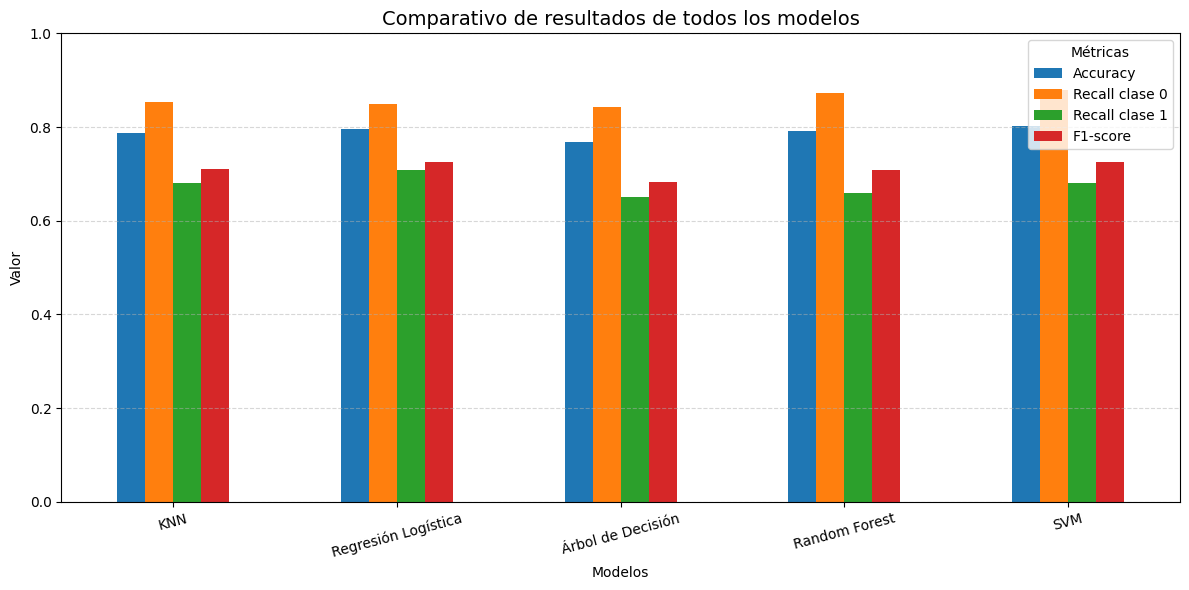

In [184]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
tabla_resultados.set_index('Modelo')[
    ['Accuracy', 'Recall clase 0', 'Recall clase 1', 'F1-score']
].plot(kind='bar', figsize=(12,6))
plt.title("Comparativo de resultados de todos los modelos", fontsize=14)
plt.xlabel("Modelos")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Métricas")
plt.tight_layout()
plt.show()

## Análisis comparativo final

Al comparar los resultados de todos los modelos, se observa que **SVM** obtuvo la **mayor accuracy (0.8022)**, lo que indica el mejor desempeño general en la clasificación de pasajeros.

En cuanto al **recall de la clase 0 (No sobrevivió)**, SVM también presentó el mejor resultado con **0.8788**, seguido de Random Forest con **0.8727**. Esto demuestra que ambos modelos identifican muy bien a los pasajeros que no sobrevivieron.

Para la **clase 1 (Sobrevivió)**, el mejor desempeño fue de **Regresión Logística (0.7087)**, lo cual indica que este modelo detecta mejor a los sobrevivientes reales.

Respecto al **F1-score**, la **Regresión Logística (0.7264)** y **SVM (0.7254)** mostraron los valores más altos, evidenciando un mejor equilibrio entre precisión y recall.

En conclusión, **SVM y Regresión Logística fueron los modelos con mejor desempeño**, destacando SVM por su accuracy y Regresión Logística por su capacidad para detectar sobrevivientes.


#**Parte 5. Recomendaciones técnicas**


